In [1]:
# краткая документация по назначению ноутбука
"""
назначение: поиск burst-паттернов активности в динамическом графе elliptic.
основные шаги: загрузка csv, построение directed-графа, расчет временных
burst-признаков, rule-based baseline, isolation forest, опциональный lstm/gru.
зависимости и данные: pandas, numpy, networkx, sklearn, matplotlib, seaborn,
опционально torch; elliptic_txs_features.csv, elliptic_txs_classes.csv,
elliptic_txs_edgelist.csv.
ключевые переменные:
- temporal_activity: агрегаты входящих, исходящих и общих событий по txid и time_step.
- burst_features: node-time таблица z-score активности и итоговых burst score.
- graph: directed-граф для локальных ego-subgraph вокруг burst-кандидатов.
- ranking_metrics: precision@k, recall@k и average precision для сравнения score.
- activity_matrix: матрица временных рядов активности для gru/lstm блока.
принцип функций:
- robust_zscore получает числовой вектор и возвращает устойчивое отклонение от медианы.
- build_burst_features объединяет события, локальную структуру и временные z-score.
- evaluate_ranking получает score и метки, возвращает качество top-k отбора.
- forecasting error получает прошлую активность узла и возвращает нормированную ошибку прогноза.
гипотезы:
- резкий рост активности внутри time_step может указывать на suspicious burst.
- локальный burst вокруг соседей информативнее одиночной степени узла.
- unsupervised score нужен как ranking, а не как окончательная разметка класса.
"""

from pathlib import Path
import shutil
import warnings

from IPython.display import display
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.metrics import average_precision_score, precision_recall_curve
from sklearn.preprocessing import MinMaxScaler, StandardScaler

try:
    import torch
except ImportError:
    torch = None

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu") if torch else "cpu"
KAGGLE_WORKING = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path.cwd()
VIS_DIR = KAGGLE_WORKING / "burst_visualizations"
VIS_DIR.mkdir(parents=True, exist_ok=True)


def save_plot(fig, filename: str) -> Path:
    """сохраняет matplotlib figure в PNG и показывает её в ноутбуке."""
    output_path = VIS_DIR / filename
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    print(f"Saved visualization: {output_path}")
    display(fig)
    plt.close(fig)
    return output_path


print(f"Device: {DEVICE}")
print(f"Visualization directory: {VIS_DIR}")
sns.set_theme(style="whitegrid")

Device: cuda


# Burst-паттерны в динамическом графе Elliptic

Цель ноутбука: найти резкие всплески активности вокруг транзакций в динамическом графе Elliptic и сформировать признаки для основной задачи классификации `licit / illicit`.

Логика эксперимента:

1. Построить динамические события по ребрам графа.
2. Рассчитать burst-признаки для узлов по временным шагам.
3. Сделать rule-based baseline по z-score активности.
4. Обучить unsupervised Isolation Forest на burst-признаках.
5. Опционально проверить LSTM/GRU forecasting error для временных рядов активности.
6. Экспортировать признаки для интеграции с node classification.

## Методологическая привязка

Ноутбук опирается на три идеи из литературы и адаптирует их к Elliptic:

- RUSH-style burst detection: поток рёбер во времени, свежая активность важнее старой, кандидаты ищутся по локальному росту активности.
- Hybrid anomaly detection: Isolation Forest применяется к агрегированным z-score признакам активности.
- STGNN / temporal forecasting: резкий всплеск можно искать через ошибку прогноза временного ряда активности.

Для темы ВКР это не только детекция аномалий, но и оптимизационная постановка: нужно ранжировать ограниченное число узлов и локальных подграфов для проверки так, чтобы максимизировать обнаружение подозрительных транзакций.

In [2]:
# project_root и data_candidates позволяют запускать ноутбук локально и в разных layout kaggle.
PROJECT_ROOT = Path.cwd()
DATA_CANDIDATES = [
    Path(
        "/kaggle/input/datasets/organizations/ellipticco/"
        "elliptic-data-set/elliptic_bitcoin_dataset"
    ),
    Path("/kaggle/input/elliptic-data-set/elliptic_bitcoin_dataset"),
    PROJECT_ROOT / "elliptic_bitcoin_dataset",
    PROJECT_ROOT / "data" / "elliptic_bitcoin_dataset",
    PROJECT_ROOT.parent / "input" / "elliptic-data-set" / "elliptic_bitcoin_dataset",
]


# вход: возможные директории; выход: первая папка, где лежат все три csv elliptic.
def find_data_dir(candidates):
    required = {
        "elliptic_txs_features.csv",
        "elliptic_txs_classes.csv",
        "elliptic_txs_edgelist.csv",
    }
    checked = []
    for candidate in candidates:
        checked.append(str(candidate))
        if candidate.exists():
            names = {path.name for path in candidate.iterdir()}
            if required.issubset(names):
                return candidate
    checked_paths = "\n".join(checked)
    raise FileNotFoundError(
        "Elliptic CSV files were not found. Checked paths:\n"
        f"{checked_paths}"
    )


DATA_DIR = find_data_dir(DATA_CANDIDATES)
FEATURES_PATH = DATA_DIR / "elliptic_txs_features.csv"
CLASSES_PATH = DATA_DIR / "elliptic_txs_classes.csv"
EDGES_PATH = DATA_DIR / "elliptic_txs_edgelist.csv"

print(f"Data directory: {DATA_DIR}")

Data directory: /kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset


In [3]:
# вход: пути к features, classes и edges; выход: таблица узлов с label и таблица ребер.
def load_elliptic(features_path, classes_path, edges_path):
    features = pd.read_csv(features_path, header=None)
    feature_columns = ["txId", "time_step"] + [
        f"feature_{idx}" for idx in range(1, features.shape[1] - 1)
    ]
    features.columns = feature_columns

    classes = pd.read_csv(classes_path)
    edges = pd.read_csv(edges_path)

    # label кодирует только известные классы: 1 для illicit, 0 для licit, unknown остается nan.
    classes["class"] = classes["class"].astype(str)
    classes["label"] = classes["class"].map({"1": 1, "2": 0})
    classes["class_name"] = classes["class"].map(
        {"1": "illicit", "2": "licit", "unknown": "unknown"}
    ).fillna("unknown")

    nodes = features.merge(classes, on="txId", how="left")
    return nodes, edges


nodes_df, edges_df = load_elliptic(FEATURES_PATH, CLASSES_PATH, EDGES_PATH)

print(f"Nodes: {len(nodes_df)}")
print(f"Edges: {len(edges_df)}")
print(f"Time steps: {nodes_df['time_step'].nunique()}")
print(f"Labeled nodes: {nodes_df['label'].notna().sum()}")

nodes_df.head()

Nodes: 203769
Edges: 234355
Time steps: 49
Labeled nodes: 46564


,txId,time_step,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_159,feature_160,feature_161,feature_162,feature_163,feature_164,feature_165,class,label,class_name
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,...,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown,NaN,unknown
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,...,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792,unknown,NaN,unknown
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,...,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792,unknown,NaN,unknown
3,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,...,0.241406,1.072793,0.085530,-0.131155,0.677799,-0.120613,-0.119792,2,0.0,licit
4,230460314,1,1.011523,-0.081127,-1.201369,1.153668,0.333276,1.312656,-0.061584,-0.163523,...,0.579382,0.018279,0.277775,0.326394,1.293750,0.178136,0.179117,unknown,NaN,unknown


In [4]:
# G хранит directed-граф транзакций, на котором считаются степени и соседская активность.
G = nx.from_pandas_edgelist(
    edges_df,
    source="txId1",
    target="txId2",
    create_using=nx.DiGraph(),
)

# node_time и node_label дают быстрый доступ к timestep и разметке по txId.
node_time = nodes_df.set_index("txId")["time_step"].to_dict()
node_label = nodes_df.set_index("txId")["label"].to_dict()

# static_degree добавляет базовую графовую активность узла вне временного разреза.
static_degree = pd.DataFrame({
    "txId": list(G.nodes()),
    "in_degree": [G.in_degree(node) for node in G.nodes()],
    "out_degree": [G.out_degree(node) for node in G.nodes()],
})
static_degree["degree"] = static_degree["in_degree"] + static_degree["out_degree"]

nodes_df = nodes_df.merge(static_degree, on="txId", how="left")
nodes_df[["in_degree", "out_degree", "degree"]] = nodes_df[
    ["in_degree", "out_degree", "degree"]
].fillna(0)

print(f"Graph nodes: {G.number_of_nodes()}")
print(f"Graph edges: {G.number_of_edges()}")
print(f"Is DAG: {nx.is_directed_acyclic_graph(G)}")

Graph nodes: 203769
Graph edges: 234355
Is DAG: True


## Rule-based Burst Baseline

В Elliptic нет открытых BTC-сумм по ребрам, поэтому burst оценивается через proxy-признаки:

- число входящих и исходящих событий во временном шаге;
- статическая степень узла;
- активность соседей;
- агрегат по анонимизированным локальным признакам как `feature_volume_proxy`.

Детектор не использует метки при поиске кандидатов. Метки нужны только для оценки качества на размеченной части.

In [5]:
# вход: значения внутри timestep; выход: устойчивый z-score через median и mad.
def robust_zscore(values):
    median = np.nanmedian(values)
    mad = np.nanmedian(np.abs(values - median))
    if mad == 0 or np.isnan(mad):
        std = np.nanstd(values)
        if std == 0 or np.isnan(std):
            return np.zeros_like(values, dtype=float)
        return (values - np.nanmean(values)) / std
    return 0.6745 * (values - median) / mad


# вход: series score; выход: значения 0..1 для смешивания разных компонент burst-score.
def minmax(series):
    values = series.to_numpy().reshape(-1, 1)
    return MinMaxScaler().fit_transform(values).ravel()


# вход: edges и время узлов; выход: события входящей/исходящей активности по txId и timestep.
def build_temporal_edge_events(edges, node_time_map):
    edge_events = edges.copy()
    edge_events["src_time"] = edge_events["txId1"].map(node_time_map)
    edge_events["dst_time"] = edge_events["txId2"].map(node_time_map)
    edge_events = edge_events.dropna(subset=["src_time", "dst_time"])
    # event_time привязывает ребро к более позднему из двух timestep, когда связь становится наблюдаемой.
    edge_events["event_time"] = edge_events[["src_time", "dst_time"]].max(axis=1)
    edge_events["event_time"] = edge_events["event_time"].astype(int)

    src_events = edge_events[["txId1", "event_time"]].rename(
        columns={"txId1": "txId"}
    )
    src_events["out_events"] = 1
    src_events["in_events"] = 0

    dst_events = edge_events[["txId2", "event_time"]].rename(
        columns={"txId2": "txId"}
    )
    dst_events["out_events"] = 0
    dst_events["in_events"] = 1

    events = pd.concat([src_events, dst_events], ignore_index=True)
    activity = events.groupby(["txId", "event_time"], as_index=False).agg(
        in_events=("in_events", "sum"),
        out_events=("out_events", "sum"),
    )
    activity["total_events"] = activity["in_events"] + activity["out_events"]
    return activity


temporal_activity = build_temporal_edge_events(edges_df, node_time)

temporal_activity.head()

,txId,event_time,in_events,out_events,total_events
0,1076,48,1,1,2
1,2534,6,0,3,3
2,3181,34,1,112,113
3,3321,1,1,0,1
4,3889,48,0,50,50


In [6]:
# вход: узлы, временная активность и граф; выход: таблица burst-признаков и rule-based score.
def build_burst_features(nodes, temporal_activity, graph):
    feature_cols = [col for col in nodes.columns if str(col).startswith("feature_")]
    # local_feature_cols служит proxy объема признаков, так как реальные суммы транзакций в elliptic скрыты.
    local_feature_cols = feature_cols[:94] if len(feature_cols) >= 94 else feature_cols

    # base содержит одну строку на узел и текущий timestep, к нему присоединяется активность ребер.
    base = nodes[["txId", "time_step", "label", "class_name"]].copy()
    base = base.merge(
        temporal_activity,
        left_on=["txId", "time_step"],
        right_on=["txId", "event_time"],
        how="left",
    )
    base[["in_events", "out_events", "total_events"]] = base[
        ["in_events", "out_events", "total_events"]
    ].fillna(0)
    base = base.drop(columns=["event_time"])

    degree_cols = nodes[["txId", "in_degree", "out_degree", "degree"]].copy()
    base = base.merge(degree_cols, on="txId", how="left")

    feature_volume = nodes[["txId"]].copy()
    feature_volume["feature_volume_proxy"] = nodes[local_feature_cols].abs().mean(axis=1)
    base = base.merge(feature_volume, on="txId", how="left")

    # neighbor_activity измеряет локальную вспышку не только у узла, но и вокруг его соседей.
    degree_map = base.set_index("txId")["degree"].to_dict()
    neighbor_activity = {}
    for node in base["txId"]:
        predecessors = list(graph.predecessors(node)) if node in graph else []
        successors = list(graph.successors(node)) if node in graph else []
        neighbors = set(predecessors + successors)
        neighbor_activity[node] = sum(degree_map.get(neighbor, 0) for neighbor in neighbors)
    base["neighbor_degree_sum"] = base["txId"].map(neighbor_activity).fillna(0)

    # zscore_cols нормируются внутри timestep, чтобы burst означал отклонение от соседей по времени.
    zscore_cols = [
        "in_events",
        "out_events",
        "total_events",
        "degree",
        "neighbor_degree_sum",
        "feature_volume_proxy",
    ]
    for col in zscore_cols:
        base[f"{col}_z"] = base.groupby("time_step")[col].transform(
            lambda values: robust_zscore(values.to_numpy(dtype=float))
        )

    score_cols = [
        "total_events_z",
        "degree_z",
        "neighbor_degree_sum_z",
        "feature_volume_proxy_z",
    ]
    for col in score_cols:
        clipped = base[col].clip(lower=0)
        base[f"{col}_norm"] = minmax(clipped)

    # burst_score_rule объединяет собственную, соседскую и feature-активность в один ранжирующий score.
    base["burst_score_rule"] = (
        0.35 * base["total_events_z_norm"]
        + 0.25 * base["degree_z_norm"]
        + 0.25 * base["neighbor_degree_sum_z_norm"]
        + 0.15 * base["feature_volume_proxy_z_norm"]
    )
    return base


burst_features = build_burst_features(nodes_df, temporal_activity, G)

print(f"Burst feature rows: {len(burst_features)}")
burst_features.sort_values("burst_score_rule", ascending=False).head(10)

Burst feature rows: 203769


,txId,time_step,label,class_name,in_events,out_events,total_events,in_degree,out_degree,degree,...,out_events_z,total_events_z,degree_z,neighbor_degree_sum_z,feature_volume_proxy_z,total_events_z_norm,degree_z_norm,neighbor_degree_sum_z_norm,feature_volume_proxy_z_norm,burst_score_rule
94301,2984918,22,0.0,licit,1,472,473,1,472,473,...,74.743195,317.6895,317.6895,210.781250,23.372169,1.000000,1.000000,0.564079,0.106498,0.756995
51371,43388675,10,0.0,licit,284,0,284,284,0,284,...,-0.770328,190.2090,190.2090,363.555500,14.368026,0.598726,0.598726,0.972924,0.065470,0.612287
130,89273,1,0.0,licit,1,288,289,1,288,289,...,86.211160,193.5815,193.5815,292.733000,68.554189,0.609342,0.609342,0.783394,0.312375,0.608310
51437,68705820,10,0.0,licit,247,0,247,247,0,247,...,-0.770328,165.2525,165.2525,305.885750,12.364875,0.520170,0.520170,0.818592,0.056342,0.525201
19138,279187194,4,0.0,licit,211,0,211,211,0,211,...,-0.953472,140.9705,140.9705,373.673000,10.733530,0.443737,0.443737,1.000000,0.048909,0.523578
148292,30699343,37,0.0,licit,241,0,241,241,0,241,...,-1.044967,161.2055,161.2055,173.009250,37.835622,0.507431,0.507431,0.462996,0.172403,0.446068
51567,43397277,10,0.0,licit,182,0,182,182,0,182,...,-0.770328,121.4100,121.4100,244.506250,9.738568,0.382166,0.382166,0.654332,0.044375,0.399539
35892,96576418,7,0.0,licit,239,0,239,239,0,239,...,-0.953312,159.8565,159.8565,132.202000,7.967875,0.503185,0.503185,0.353791,0.036307,0.395804
51392,68706499,10,0.0,licit,178,0,178,178,0,178,...,-0.770328,118.7120,118.7120,220.898750,9.924410,0.373673,0.373673,0.591155,0.045222,0.378776
24761,225859042,5,NaN,unknown,212,0,212,212,0,212,...,-0.828036,141.6450,141.6450,147.940333,6.348209,0.445860,0.445860,0.395909,0.028926,0.370832


In [7]:
# вход: score-колонка; выход: precision@k, recall@k и average precision на размеченных узлах.
def evaluate_ranking(frame, score_col, label_col="label", top_fracs=(0.001, 0.005, 0.01, 0.05)):
    labeled = frame.dropna(subset=[label_col]).copy()
    labeled[label_col] = labeled[label_col].astype(int)
    labeled = labeled.sort_values(score_col, ascending=False)

    rows = []
    positives = labeled[label_col].sum()
    # top_fracs имитируют расследование ограниченного числа самых подозрительных узлов.
    for frac in top_fracs:
        k = max(1, int(len(labeled) * frac))
        top_k = labeled.head(k)
        true_positive = top_k[label_col].sum()
        rows.append({
            "score": score_col,
            "top_frac": frac,
            "top_k": k,
            "precision_at_k": true_positive / k,
            "recall_at_k": true_positive / positives if positives else np.nan,
            "illicit_found": int(true_positive),
        })

    ap = average_precision_score(labeled[label_col], labeled[score_col])
    metrics = pd.DataFrame(rows)
    metrics["average_precision"] = ap
    return metrics


rule_metrics = evaluate_ranking(burst_features, "burst_score_rule")
rule_metrics

,score,top_frac,top_k,precision_at_k,recall_at_k,illicit_found,average_precision
0,burst_score_rule,0.001,46,0.108696,0.001100,5,0.069003
1,burst_score_rule,0.005,232,0.051724,0.002640,12,0.069003
2,burst_score_rule,0.010,465,0.045161,0.004620,21,0.069003
3,burst_score_rule,0.050,2328,0.012457,0.006381,29,0.069003


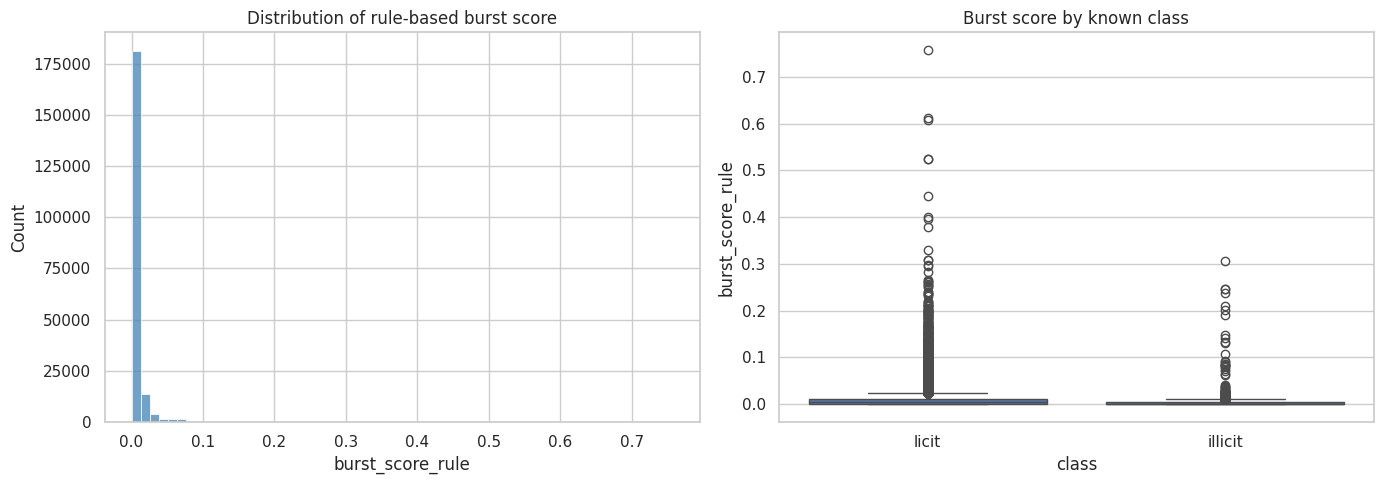

In [8]:
# визуализация проверяет, выделяет ли rule-based score отдельный хвост и отличается ли он по классам.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    burst_features["burst_score_rule"],
    bins=60,
    ax=axes[0],
    color="steelblue",
)
axes[0].set_title("Distribution of rule-based burst score")
axes[0].set_xlabel("burst_score_rule")

labeled = burst_features.dropna(subset=["label"]).copy()
sns.boxplot(
    data=labeled,
    x="class_name",
    y="burst_score_rule",
    ax=axes[1],
)
axes[1].set_title("Burst score by known class")
axes[1].set_xlabel("class")
axes[1].set_ylabel("burst_score_rule")

plt.tight_layout()
save_plot(fig, "burst_score_distribution_and_classes.png")

In [ ]:
# визуализация проверяет:
# 1) есть ли у rule-based burst score выраженный правый хвост;
# 2) отличаются ли значения score между известными классами.

score_col = "burst_score_rule"

plot_df = burst_features.copy()
plot_df[score_col] = pd.to_numeric(plot_df[score_col], errors="coerce")
plot_df = plot_df.dropna(subset=[score_col])

# ограничиваем ось по верхнему перцентилю, чтобы хвост не сжимал весь график
q99 = plot_df[score_col].quantile(0.99)
q995 = plot_df[score_col].quantile(0.995)

# если из-за большого числа нулей квантиль получился слишком маленьким
x_max = q995 if q995 > 0 else plot_df[score_col].max()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Распределение burst_score_rule
sns.histplot(
    data=plot_df,
    x=score_col,
    bins=60,
    ax=axes[0],
    color="steelblue",
    edgecolor="white"
)

axes[0].set_xlim(0, x_max)
axes[0].set_yscale("log")
axes[0].set_title("Distribution of rule-based burst score\nzoomed to 99.5 percentile")
axes[0].set_xlabel("burst_score_rule")
axes[0].set_ylabel("Count, log scale")

# добавим линию 99-го перцентиля
axes[0].axvline(
    q99,
    color="darkred",
    linestyle="--",
    linewidth=1.5,
    label=f"99th percentile = {q99:.4f}"
)
axes[0].legend()


# 2. Сравнение score по известным классам
labeled = plot_df.dropna(subset=["label", "class_name"]).copy()

sns.boxplot(
    data=labeled,
    x="class_name",
    y=score_col,
    ax=axes[1],
    showfliers=False
)

# добавляем точки, но только сэмпл, чтобы график не превратился в шум
sample_size = min(5000, len(labeled))
labeled_sample = labeled.sample(sample_size, random_state=42)

sns.stripplot(
    data=labeled_sample,
    x="class_name",
    y=score_col,
    ax=axes[1],
    color="black",
    alpha=0.25,
    size=2,
    jitter=0.25
)

axes[1].set_ylim(0, x_max)
axes[1].set_title("Burst score by known class\noutliers hidden, zoomed scale")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("burst_score_rule")

plt.tight_layout()
save_plot(fig, "burst_score_distribution_and_classes_fixed.png")
plt.show()

## Burst Subgraph Scoring

Для связи с задачей поиска подозрительных подграфов строится локальный `ego-subgraph` вокруг burst-кандидата.

Score подграфа учитывает:

- burst-score центрального узла;
- средний burst-score в окрестности;
- плотность локального подграфа;
- размер окрестности.

Метки не входят в score и используются только для анализа найденных кандидатов.

In [9]:
# вход: центр и радиус; выход: ego-узлы вокруг кандидата без учета направления ребер.
def get_directed_ego_nodes(graph, node, radius=1):
    if node not in graph:
        return {node}
    undirected = graph.to_undirected(as_view=True)
    return set(nx.ego_graph(undirected, node, radius=radius).nodes())


# вход: graph и burst_features; выход: ranking локальных subgraph вокруг top burst-кандидатов.
def score_burst_subgraphs(graph, features, top_n=200, radius=1):
    feature_map = features.set_index("txId")
    candidates = features.sort_values("burst_score_rule", ascending=False).head(top_n)
    rows = []

    for _, candidate in candidates.iterrows():
        center = candidate["txId"]
        ego_nodes = get_directed_ego_nodes(graph, center, radius=radius)
        subgraph = graph.subgraph(ego_nodes).copy()
        known_nodes = [node for node in ego_nodes if node in feature_map.index]
        local_scores = feature_map.loc[known_nodes, "burst_score_rule"]
        local_labels = feature_map.loc[known_nodes, "label"].dropna()

        density = nx.density(subgraph.to_undirected()) if len(subgraph) > 1 else 0
        illicit_share = (
            local_labels.astype(int).mean() if len(local_labels) > 0 else np.nan
        )
        # subgraph_score усиливает кандидата, если вокруг него тоже высокая burst-активность и плотность.
        subgraph_score = (
            0.50 * candidate["burst_score_rule"]
            + 0.30 * local_scores.mean()
            + 0.20 * density
        )

        rows.append({
            "center_txId": center,
            "center_time_step": candidate["time_step"],
            "n_nodes": subgraph.number_of_nodes(),
            "n_edges": subgraph.number_of_edges(),
            "density": density,
            "center_burst_score": candidate["burst_score_rule"],
            "mean_local_burst_score": local_scores.mean(),
            "burst_subgraph_score": subgraph_score,
            "known_illicit_share": illicit_share,
        })

    return pd.DataFrame(rows).sort_values(
        "burst_subgraph_score", ascending=False
    )


burst_subgraphs = score_burst_subgraphs(G, burst_features, top_n=200, radius=1)
burst_subgraphs.head(10)

,center_txId,center_time_step,n_nodes,n_edges,density,center_burst_score,mean_local_burst_score,burst_subgraph_score,known_illicit_share
0,2984918,22,474,547,0.004880,0.756995,0.062315,0.398168,0.00
1,43388675,10,285,358,0.008846,0.612287,0.078293,0.331401,0.00
2,89273,1,290,314,0.007493,0.608310,0.072421,0.327380,0.00
128,69599555,35,2,1,1.000000,0.150000,0.113918,0.309176,0.00
129,69727711,35,2,1,1.000000,0.149465,0.113651,0.308828,0.00
4,279187194,4,212,266,0.011893,0.523578,0.072009,0.285771,0.00
3,68705820,10,248,320,0.010448,0.525201,0.067726,0.285008,0.00
5,30699343,37,242,274,0.009396,0.446068,0.059625,0.242801,0.00
196,92107631,33,4,4,0.666667,0.128172,0.147687,0.241726,0.25
6,43397277,10,183,220,0.013211,0.399539,0.063842,0.221564,0.00


## Unsupervised ML: Isolation Forest

Isolation Forest используется как unsupervised detector. Он не обучается на `licit / illicit`, а ищет узлы с нетипичной комбинацией burst-признаков.

Это хороший промежуточный вариант между rule-based baseline и temporal GNN.

In [10]:
# iforest_cols задает признаки для unsupervised поиска узлов с нетипичной burst-активностью.
iforest_cols = [
    "in_events_z",
    "out_events_z",
    "total_events_z",
    "degree_z",
    "neighbor_degree_sum_z",
    "feature_volume_proxy_z",
]

iforest_frame = burst_features[iforest_cols].replace([np.inf, -np.inf], np.nan)
iforest_frame = iforest_frame.fillna(0)

# стандартизация выравнивает масштаб z-признаков перед isolation forest.
scaler = StandardScaler()
iforest_input = scaler.fit_transform(iforest_frame)

iforest = IsolationForest(
    n_estimators=300,
    contamination=0.02,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
iforest.fit(iforest_input)

burst_features["burst_score_iforest"] = -iforest.decision_function(iforest_input)
burst_features["is_burst_iforest"] = iforest.predict(iforest_input) == -1
burst_features["burst_score_iforest_norm"] = minmax(
    burst_features["burst_score_iforest"]
)

iforest_metrics = evaluate_ranking(burst_features, "burst_score_iforest_norm")
iforest_metrics

,score,top_frac,top_k,precision_at_k,recall_at_k,illicit_found,average_precision
0,burst_score_iforest_norm,0.001,46,0.021739,0.000220,1,0.06901
1,burst_score_iforest_norm,0.005,232,0.056034,0.002860,13,0.06901
2,burst_score_iforest_norm,0.010,465,0.051613,0.005281,24,0.06901
3,burst_score_iforest_norm,0.050,2328,0.012027,0.006161,28,0.06901


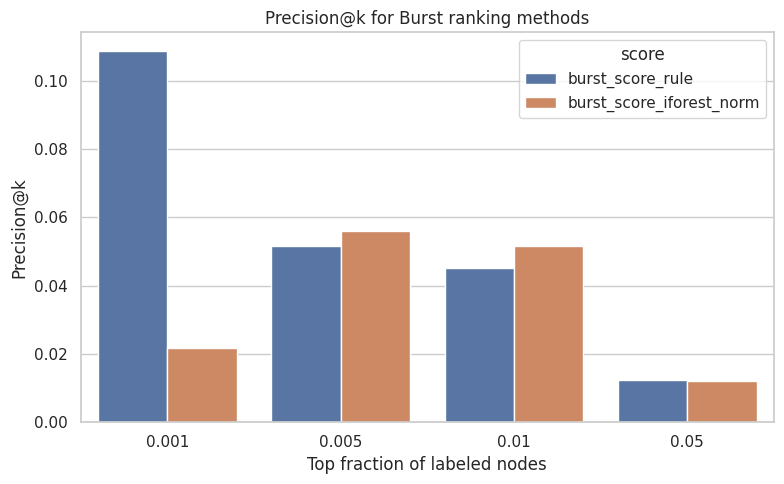

,score,top_frac,top_k,precision_at_k,recall_at_k,illicit_found,average_precision
0,burst_score_rule,0.001,46,0.108696,0.001100,5,0.069003
1,burst_score_rule,0.005,232,0.051724,0.002640,12,0.069003
2,burst_score_rule,0.010,465,0.045161,0.004620,21,0.069003
3,burst_score_rule,0.050,2328,0.012457,0.006381,29,0.069003
4,burst_score_iforest_norm,0.001,46,0.021739,0.000220,1,0.069010
5,burst_score_iforest_norm,0.005,232,0.056034,0.002860,13,0.069010
6,burst_score_iforest_norm,0.010,465,0.051613,0.005281,24,0.069010
7,burst_score_iforest_norm,0.050,2328,0.012027,0.006161,28,0.069010


In [11]:
# comparison сопоставляет rule-based score и isolation forest по top-k качеству.
comparison = pd.concat([rule_metrics, iforest_metrics], ignore_index=True)
comparison.sort_values(["top_frac", "score"])

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=comparison,
    x="top_frac",
    y="precision_at_k",
    hue="score",
    ax=ax,
)
ax.set_title("Precision@k for Burst ranking methods")
ax.set_xlabel("Top fraction of labeled nodes")
ax.set_ylabel("Precision@k")
plt.tight_layout()
save_plot(fig, "burst_ranking_precision_at_k.png")

comparison

## Опционально: LSTM/GRU Forecasting Error

В классическом Elliptic узел является транзакцией, поэтому полноценный длинный временной ряд для каждого узла ограничен. Блок ниже использует временные ряды активности для наиболее динамичных узлов и оценивает аномальность через ошибку прогноза.

Если `torch` недоступен, секция будет пропущена без ошибки.

In [12]:
# вход: temporal activity; выход: матрица txId x timestep для gru-прогноза активности.
def build_node_activity_matrix(activity, top_nodes=2000):
    time_values = sorted(nodes_df["time_step"].unique())
    # dynamic_nodes ограничивает обучение самыми активными узлами, чтобы матрица оставалась компактной.
    dynamic_nodes = (
        activity.groupby("txId")["total_events"]
        .sum()
        .sort_values(ascending=False)
        .head(top_nodes)
        .index
    )
    matrix = (
        activity[activity["txId"].isin(dynamic_nodes)]
        .pivot_table(
            index="txId",
            columns="event_time",
            values="total_events",
            aggfunc="sum",
            fill_value=0,
        )
        .reindex(columns=time_values, fill_value=0)
    )
    return matrix


activity_matrix = build_node_activity_matrix(temporal_activity, top_nodes=2000)
print(f"Activity matrix shape: {activity_matrix.shape}")

if torch is None:
    print("Torch is not installed, GRU section skipped")
else:
    from torch import nn
    from torch.utils.data import DataLoader, TensorDataset

    # модель GRUForecaster предсказывает следующий timestep активности по предыдущей динамике узла.
    class GRUForecaster(nn.Module):
        def __init__(self, hidden_size=16):
            super().__init__()
            self.gru = nn.GRU(input_size=1, hidden_size=hidden_size, batch_first=True)
            self.head = nn.Linear(hidden_size, 1)

        def forward(self, x):
            output, _ = self.gru(x)
            return self.head(output)

    print(f"GRU device: {DEVICE}")

    # values логарифмируются, чтобы редкие сверхактивные узлы не доминировали в loss.
    values = np.log1p(activity_matrix.to_numpy(dtype=np.float32))
    train_x = torch.tensor(values[:, :-1, None], dtype=torch.float32)
    train_y = torch.tensor(values[:, 1:, None], dtype=torch.float32)

    dataset = TensorDataset(train_x, train_y)
    loader = DataLoader(dataset, batch_size=128, shuffle=True)

    model = GRUForecaster(hidden_size=16).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    loss_fn = nn.MSELoss()

    model.train()
    for epoch in range(20):
        losses = []
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(DEVICE)
            batch_y = batch_y.to(DEVICE)
            optimizer.zero_grad()
            prediction = model(batch_x)
            loss = loss_fn(prediction, batch_y)
            loss.backward()
            optimizer.step()
            losses.append(loss.item())
        if epoch in {0, 9, 19}:
            print(f"Epoch {epoch + 1}: loss {np.mean(losses):.6f}")

    model.eval()
    with torch.no_grad():
        prediction = model(train_x.to(DEVICE)).cpu().numpy().squeeze(-1)
    # errors интерпретируются как burst-score: чем хуже прогноз, тем нетипичнее временной профиль.
    errors = ((prediction - values[:, 1:]) ** 2).mean(axis=1)

    lstm_scores = pd.DataFrame({
        "txId": activity_matrix.index,
        "burst_score_gru_error": errors,
    })
    burst_features = burst_features.merge(lstm_scores, on="txId", how="left")
    burst_features["burst_score_gru_error"] = burst_features[
        "burst_score_gru_error"
    ].fillna(0)
    burst_features["burst_score_gru_error_norm"] = minmax(
        burst_features["burst_score_gru_error"]
    )
    gru_metrics = evaluate_ranking(burst_features, "burst_score_gru_error_norm")
    display(gru_metrics)

Activity matrix shape: (2000, 49)
GRU device: cuda
Epoch 1: loss 0.233306
Epoch 10: loss 0.210684
Epoch 20: loss 0.204605


,score,top_frac,top_k,precision_at_k,recall_at_k,illicit_found,average_precision
0,burst_score_gru_error_norm,0.001,46,0.217391,0.002200,10,0.09805
1,burst_score_gru_error_norm,0.005,232,0.086207,0.004400,20,0.09805
2,burst_score_gru_error_norm,0.010,465,0.053763,0.005501,25,0.09805
3,burst_score_gru_error_norm,0.050,2328,0.064863,0.033223,151,0.09805


## Экспорт Burst-признаков

Эти признаки объединяются с основной таблицей узлов и используются в `01_kaggle_elliptic-data-set-node-classification.ipynb` вместе с fan-in/fan-out и peel-chain признаками.

In [13]:
# export_dir хранит итоговые burst-признаки, subgraph-score и метрики ранжирования.
EXPORT_DIR = KAGGLE_WORKING / "outputs" / "elliptic_patterns"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# export_cols содержит только воспроизводимые признаки, пригодные для дальнейшего feature enrichment.
export_cols = [
    "txId",
    "time_step",
    "in_events",
    "out_events",
    "total_events",
    "in_events_z",
    "out_events_z",
    "total_events_z",
    "degree_z",
    "neighbor_degree_sum_z",
    "feature_volume_proxy_z",
    "burst_score_rule",
    "burst_score_iforest_norm",
    "is_burst_iforest",
]
if "burst_score_gru_error_norm" in burst_features.columns:
    export_cols.append("burst_score_gru_error_norm")

burst_feature_export = burst_features[export_cols].copy()
burst_feature_export.to_csv(
    EXPORT_DIR / "elliptic_burst_features.csv",
    index=False,
)
burst_subgraphs.to_csv(
    EXPORT_DIR / "elliptic_burst_subgraphs.csv",
    index=False,
)
comparison.to_csv(
    EXPORT_DIR / "elliptic_burst_ranking_metrics.csv",
    index=False,
)

archive_path = shutil.make_archive(
    str(KAGGLE_WORKING / "burst_visualizations_png"),
    "zip",
    VIS_DIR,
)

print(f"Exported features: {EXPORT_DIR / 'elliptic_burst_features.csv'}")
print(f"Exported subgraphs: {EXPORT_DIR / 'elliptic_burst_subgraphs.csv'}")
print(f"Exported metrics: {EXPORT_DIR / 'elliptic_burst_ranking_metrics.csv'}")
print(f"Visualization PNG directory: {VIS_DIR}")
print(f"Visualization PNG archive: {archive_path}")

Exported features: /kaggle/working/outputs/elliptic_patterns/elliptic_burst_features.csv
Exported subgraphs: /kaggle/working/outputs/elliptic_patterns/elliptic_burst_subgraphs.csv
Exported metrics: /kaggle/working/outputs/elliptic_patterns/elliptic_burst_ranking_metrics.csv


## Вывод для ВКР

Burst-паттерн можно трактовать как оптимизационную задачу ранжирования подозрительных узлов и локальных подграфов в динамическом графе.

В этом ноутбуке сравниваются:

- классический rule-based detector по z-score активности;
- unsupervised ML через Isolation Forest;
- опциональная temporal neural модель через GRU forecasting error.

Дальше burst-признаки нужно объединить с fan-in/fan-out и peel-chain признаками, а затем проверить прирост качества в основной задаче классификации транзакций.